### **Autor:** David Roca Tauste

---
---
# **ACTIVIDAD 2: VECTORIZAR TEXTO DE MANERA AUTOMÁTICA**
---
---

                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...     1
3  Subject: 4 color printing special  request add...     1
4  Subject: do not have money , get software cds ...     1
5  Subject: great nnews  hello , welcome to medzo...     1
6  Subject: here ' s a hot play in motion  homela...     1
7  Subject: save your money buy getting this thin...     1
8  Subject: undeliverable : home based business f...     1
9  Subject: save your money buy getting this thin...     1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB
None
Porcentaje de Spam = 23.8827%
Porcentaje de H

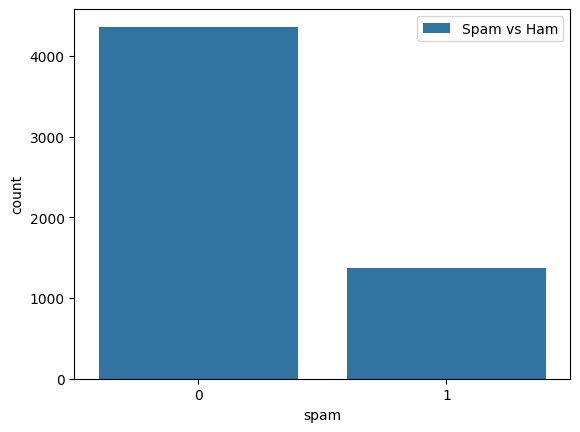

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar datos
spam_df = pd.read_csv("./emails.csv")
print(spam_df.head(10))
print(spam_df.info())

# Visualizar datos
ham = spam_df[spam_df["spam"] == 0]
spam = spam_df[spam_df["spam"] == 1]
print(f"Porcentaje de Spam = {(len(spam)/len(spam_df))*100:.4f}%")
print(f"Porcentaje de Ham = {(len(ham)/len(spam_df))*100:.4f}%")
sns.countplot(x="spam", data=spam_df, label="Spam vs Ham")
plt.show()

## ENTREGA 5: ¿Cuántos emails contiene el dataset? ¿Qué porcentaje de ellos son spam?
El dataset contiene 5728 emails. De los cuales, el 23.8827% son spam.

---

In [2]:
from sklearn.feature_extraction.text import CountVectorizer

# Aplicar la vectorización automática
c_v = CountVectorizer()
spamham_c_v = c_v.fit_transform(spam_df["text"])
print("CountVectorizer: Nombres de características:\n", c_v.get_feature_names_out())
print("CountVectorizer: diseño", spamham_c_v.shape)
label = spam_df["spam"]
X = spamham_c_v
y = label
print("Dimensiones de X", X.shape)

CountVectorizer: Nombres de características:
 ['00' '000' '0000' ... 'zzn' 'zzncacst' 'zzzz']
CountVectorizer: diseño (5728, 37303)
Dimensiones de X (5728, 37303)


## ENTREGA 6: El problema de no eliminar palabras comunes es que la cantidad de palabras o tokens que debes procesar se dispara mucho y cada una de ellas se considera una característica de los datos de entrenamiento ¿Cuántas distintas palabras ha encontrado el vectorizador?
El vectorizador ha encontrado 37303 palabras distintas.

---

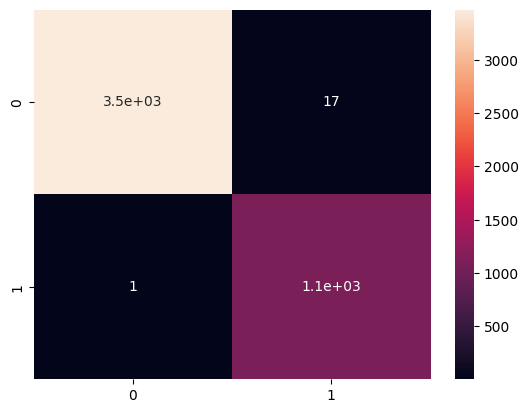

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       870
           1       0.98      1.00      0.99       276

    accuracy                           1.00      1146
   macro avg       0.99      1.00      0.99      1146
weighted avg       1.00      1.00      1.00      1146



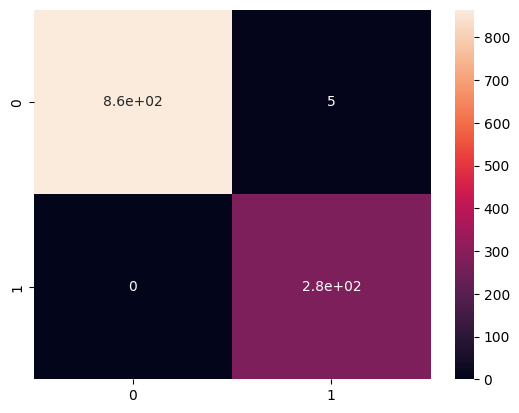

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Crear el modelo naive Bayes de tipo Multinomial
nbc = MultinomialNB()
nbc.fit(X_train, y_train)

# Imprimir resultados de validación: mapa de calor y matriz de confusión.
y_pred_train = nbc.predict(X_train)
cm = confusion_matrix(y_train, y_pred_train)
sns.heatmap(cm, annot=True)
plt.show()

y_pred_test = nbc.predict(X_test)
print(classification_report(y_test, y_pred_test))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True)
plt.show()

## ENTREGA 7: En el problema de clasificar spam que es peor, ¿Tener un falso positivo (decir que un mail es spam cuando no lo es) o un falso negativo (decir que un mail es ham cuando en realidad es spam)?
Es peor tener un falso positivo, debido a que, cuanto mayor sea esta cifra, más correos importantes (ham) no verás pensando que son spam.

### Muestra la matriz de confusión del entrenamiento y del test.
Se encuentra arriba.

### ¿Parece que generaliza bien este modelo? (argumenta la respuesta)
Aparentemente, el modelo sí que generaliza bien, ya que tanto la precisión como el recall de las dos clases es prácticamente del 100%.

### Para la del test indica donde comete más fallos cuantitativamente (5 errores, 4 errores, …) y porcentualmente (fallo 5 veces en decir que es spam de 100 emails spam que tengo, es el 5% de error).
Fallos cuantitativos:
- Falsos positivos: 5
- Falsos negativos: 0

Fallos porcentuales:
- Falsos positivos: 0'087 %
- Falsos negativos: 0%

### Pasa captura del informe de la clasificación, e indica si los valores de las métricas darían por bueno el modelo según lo que hayas respondido en la primera cuestión.
Se encuentra arriba. En mi opinión, los valores de las métricas sí darían por bueno el modelo porque estas son excelentes.